# Exercice Gestion d'actifs et Data
# ISIFAR M2 2025-2026

## 1. Les données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import networkx as nx

Première vue du dataframe

In [2]:
df = pd.read_csv("sp500.csv")
print(df.head())
print(df.describe())

         date  NVDA  AAPL  MSFT  GOOG  GOOGL  AMZN  AVGO  META  TSLA  ...  \
0  1962-01-02   NaN   NaN   NaN   NaN    NaN   NaN   NaN   NaN   NaN  ...   
1  1962-01-03   NaN   NaN   NaN   NaN    NaN   NaN   NaN   NaN   NaN  ...   
2  1962-01-04   NaN   NaN   NaN   NaN    NaN   NaN   NaN   NaN   NaN  ...   
3  1962-01-05   NaN   NaN   NaN   NaN    NaN   NaN   NaN   NaN   NaN  ...   
4  1962-01-08   NaN   NaN   NaN   NaN    NaN   NaN   NaN   NaN   NaN  ...   

   FRT  LW  CRL  CAG  MOS  LKQ  MTCH  SOLS  MOH  MHK  
0  NaN NaN  NaN  NaN  NaN  NaN   NaN   NaN  NaN  NaN  
1  NaN NaN  NaN  NaN  NaN  NaN   NaN   NaN  NaN  NaN  
2  NaN NaN  NaN  NaN  NaN  NaN   NaN   NaN  NaN  NaN  
3  NaN NaN  NaN  NaN  NaN  NaN   NaN   NaN  NaN  NaN  
4  NaN NaN  NaN  NaN  NaN  NaN   NaN   NaN  NaN  NaN  

[5 rows x 502 columns]
              NVDA          AAPL          MSFT         GOOG        GOOGL  \
count  6782.000000  11359.000000  10033.000000  5381.000000  5381.000000   
mean     13.669829     28.04872

On choisit un portefeuille de 25 actions du S&P500 et une date allant du 01/08/2022 au 01/08/2025

In [3]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df.set_index('date', inplace=True)

df = df.loc['2022-08-01':'2025-08-01'].iloc[:,0:25]

df = df.dropna(axis=1, how='any') 
print(df.head())
print(df.shape)

                 NVDA        AAPL        MSFT        GOOG       GOOGL  \
date                                                                    
2022-08-01  18.412376  158.625778  270.181824  114.620323  113.998657   
2022-08-02  18.497244  157.152557  267.081543  115.037201  114.266632   
2022-08-03  18.863672  163.163284  274.516144  117.895760  117.194511   
2022-08-04  19.185175  162.848984  275.662933  117.985100  117.303696   
2022-08-05  18.959526  162.622818  274.943787  117.339928  116.589088   

                  AMZN       AVGO        META        TSLA         LLY  ...  \
date                                                                   ...   
2022-08-01  135.389999  50.435745  158.820587  297.276672  314.633820  ...   
2022-08-02  134.160004  49.950542  159.078781  300.586670  310.799866  ...   
2022-08-03  139.520004  51.410851  167.629059  307.396667  304.616821  ...   
2022-08-04  142.570007  51.980690  169.386795  308.633331  296.812836  ...   
2022-08-05  140.8000

## 2. Stratégie momentum sur les actions
On travaille sur la moyenne mobile (fenêtre de 10 jours)

### Question 1. Calcul de la moyenne mobile

In [4]:
moving_average = df.rolling(10).mean()

### Question 2. Signaux d'achat et de vente

In [5]:
buy_order = (df > moving_average) & (df.shift(1) <= moving_average.shift(1))
sell_order = (df < moving_average) & (df.shift(1) >= moving_average.shift(1))

### Question 3. Construction de la position et calcul du PnL

In [6]:
signal = pd.DataFrame(0, index=df.index, columns=df.columns)
signal[buy_order]  = 1
signal[sell_order] = -1

# Construire la position
position_sign = signal.replace(0, np.nan).ffill().fillna(0)

capital = 100
n_actions = df.shape[1]
capital_per_action = capital / n_actions

# Nombre d'actions détenues
position = position_sign * (capital_per_action / df)

# Calcul du PnL
price_change = df.diff()
pnl = position.shift(1) * price_change
portfolio_pnl = pnl.sum(axis=1)
portfolio_value = capital + portfolio_pnl.cumsum()

# Résultat
print("Valeur finale du portefeuille :", portfolio_value.iloc[-1])

Valeur finale du portefeuille : 123.3177750476593


### Question 4. Optimisation de la fenêtre m (5 à 20 jours)

     m  Rendement_annuel
0    5         -0.064455
1    6         -0.003922
2    7          0.078071
3    8          0.200638
4    9          0.237370
5   10          0.233178
6   11          0.261031
7   12          0.247469
8   13          0.198280
9   14          0.250258
10  15          0.191572
11  16          0.179141
12  17          0.198360
13  18          0.225706
14  19          0.252698
15  20          0.273736


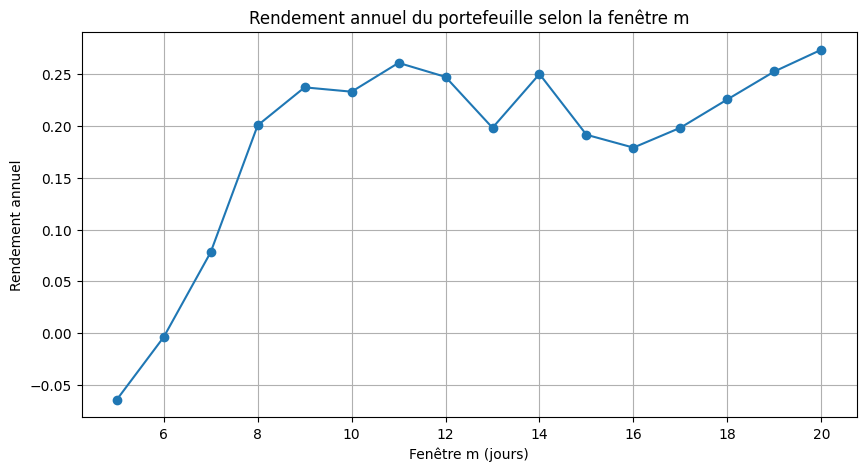

In [7]:
m_values = range(5, 21)   # 5 à 20
annual_return = []

for m in m_values:
    moving_average = df.rolling(m).mean()
    
    buy_order  = (df > moving_average) & (df.shift(1) <= moving_average.shift(1))
    sell_order = (df < moving_average) & (df.shift(1) >= moving_average.shift(1))
    
    signal = pd.DataFrame(0, index=df.index, columns=df.columns)
    signal[buy_order]  = 1
    signal[sell_order] = -1
    
    position_sign = signal.replace(0, np.nan).ffill().fillna(0)
    position = position_sign * (capital_per_action / df)
    
    price_change = df.diff()
    pnl = position.shift(1) * price_change
    portfolio_pnl = pnl.sum(axis=1)
    portfolio_value = capital + portfolio_pnl.cumsum()
    
    total_return = (portfolio_value.iloc[-1] - capital) / capital
    annual_return.append(total_return)

# Tableau des rendements
tableau_rendements = pd.DataFrame({
    'm': list(m_values),
    'Rendement_annuel': annual_return
})
print(tableau_rendements)

# Graphique
plt.figure(figsize=(10,5))
plt.plot(tableau_rendements['m'], tableau_rendements['Rendement_annuel'], marker='o')
plt.title("Rendement annuel du portefeuille selon la fenêtre m")
plt.xlabel("Fenêtre m (jours)")
plt.ylabel("Rendement annuel")
plt.grid(True)
plt.show()

## 3. Changement de variables par PCA

### Question 5. Calcul des log-rendements et Scree plot

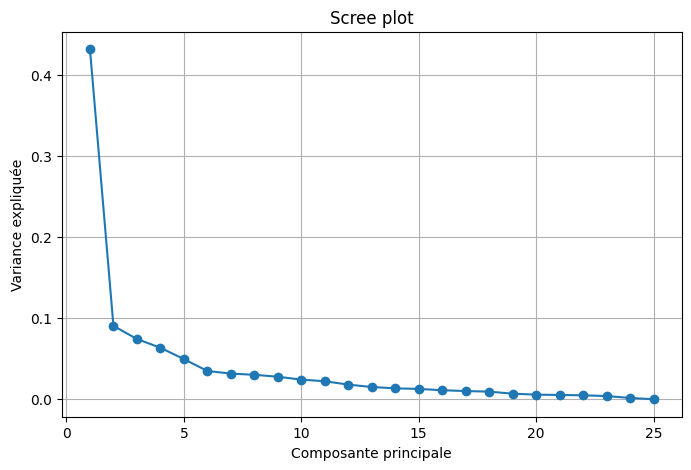

In [11]:
log_returns = np.log(df / df.shift(1)).dropna()

# Nombre de composantes = N
pca = PCA(n_components=log_returns.shape[1])
pca.fit(log_returns)

# Variance expliquée par chaque composante
explained_variance_ratio = pca.explained_variance_ratio_

# Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, 'o-', markersize=6)
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée')
plt.title('Scree plot')
plt.grid(True)
plt.show()

In [ ]:
n_components = 3
pca = PCA(n_components=n_components)
pca.fit(log_returns)

# Vecteurs propres (chaque ligne = une composante principale)
eigenvectors = pca.components_

### Question 6. Simplification des vecteurs propres

In [14]:
def simplify_eigenvectors(eigenvectors, threshold):
    v = eigenvectors.copy()
    v[np.abs(v) < threshold] = 0
    v = np.sign(v)
    norm = np.linalg.norm(v, axis=1, keepdims=True)
    norm[norm==0] = 1
    v = v / norm    
    return v

simplified = simplify_eigenvectors(eigenvectors, 0.1)
print(simplified)

[[ 0.25        0.25        0.25        0.25        0.25        0.25
   0.25        0.25        0.25        0.          0.25        0.
   0.25        0.          0.          0.25        0.25        0.
   0.25        0.          0.25        0.          0.25        0.
   0.        ]
 [-0.30151134  0.         -0.30151134 -0.30151134 -0.30151134 -0.30151134
  -0.30151134 -0.30151134  0.30151134  0.          0.          0.
  -0.30151134  0.          0.          0.          0.          0.
   0.30151134  0.          0.          0.         -0.30151134  0.
   0.        ]
 [-0.57735027  0.          0.          0.          0.          0.
   0.          0.          0.57735027  0.          0.          0.
   0.          0.          0.          0.          0.          0.
  -0.57735027  0.          0.          0.          0.          0.
   0.        ]]


### Question 7. Stratégie CTA basée sur les composantes principales

Valeur finale du portefeuille CTA : 101.19543117643737


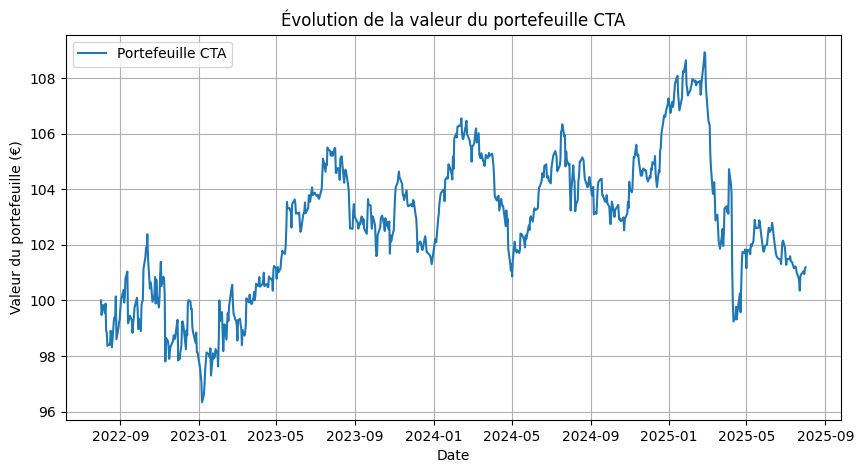

In [15]:
capital = 100
n_assets = log_returns.shape[1]
capital_per_asset = capital / n_assets

k = simplified.shape[0]  # nombre de vecteurs propres

position_units = pd.DataFrame(0.0, index=log_returns.index, columns=log_returns.columns)

for i in range(k):
    v = simplified[i] 
    factor_signal = log_returns.dot(v)
    signal = np.sign(factor_signal).values[:, np.newaxis]  
    position_units += signal * v

position_value = position_units * capital_per_asset

pnl = position_value.shift(1) * log_returns 
portfolio_pnl = pnl.sum(axis=1)
portfolio_value = capital + portfolio_pnl.cumsum()

print("Valeur finale du portefeuille CTA :", portfolio_value.iloc[-1])

# Graphique
plt.figure(figsize=(10,5))
plt.plot(portfolio_value, label="Portefeuille CTA")
plt.title("Évolution de la valeur du portefeuille CTA")
plt.xlabel("Date")
plt.ylabel("Valeur du portefeuille (€)")
plt.grid(True)
plt.legend()
plt.show()

## 4. Minimum Spanning Tree

### Question 8. Graphe des corrélations

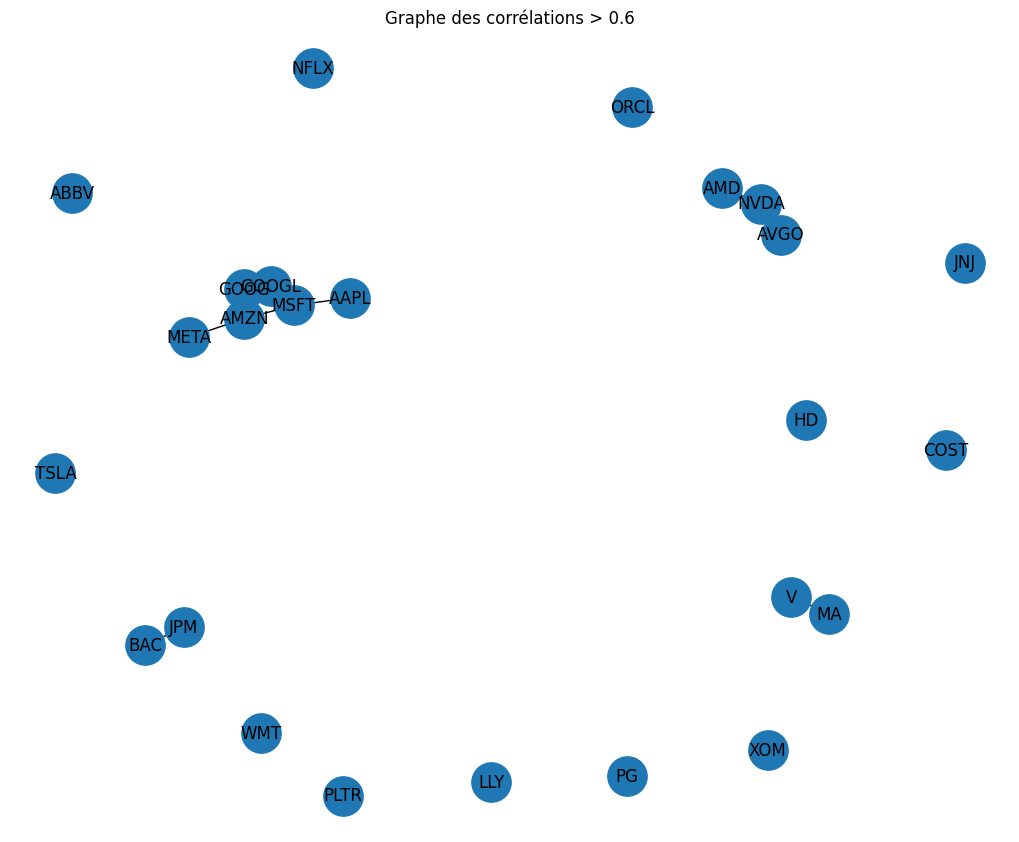

In [16]:
corr_matrix = log_returns.corr()
corr_threshold = 0.6

G = nx.Graph()

# Ajouter les noeuds
for stock in corr_matrix.columns:
    G.add_node(stock)

# Ajouter les arêtes si corr > seuil
for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i != j and corr_matrix.loc[i, j] > corr_threshold:
            G.add_edge(i, j, weight=corr_matrix.loc[i, j])

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=800)
plt.title(f"Graphe des corrélations > {corr_threshold}")
plt.show()

### Question 9. Minimum Spanning Tree basé sur les corrélations

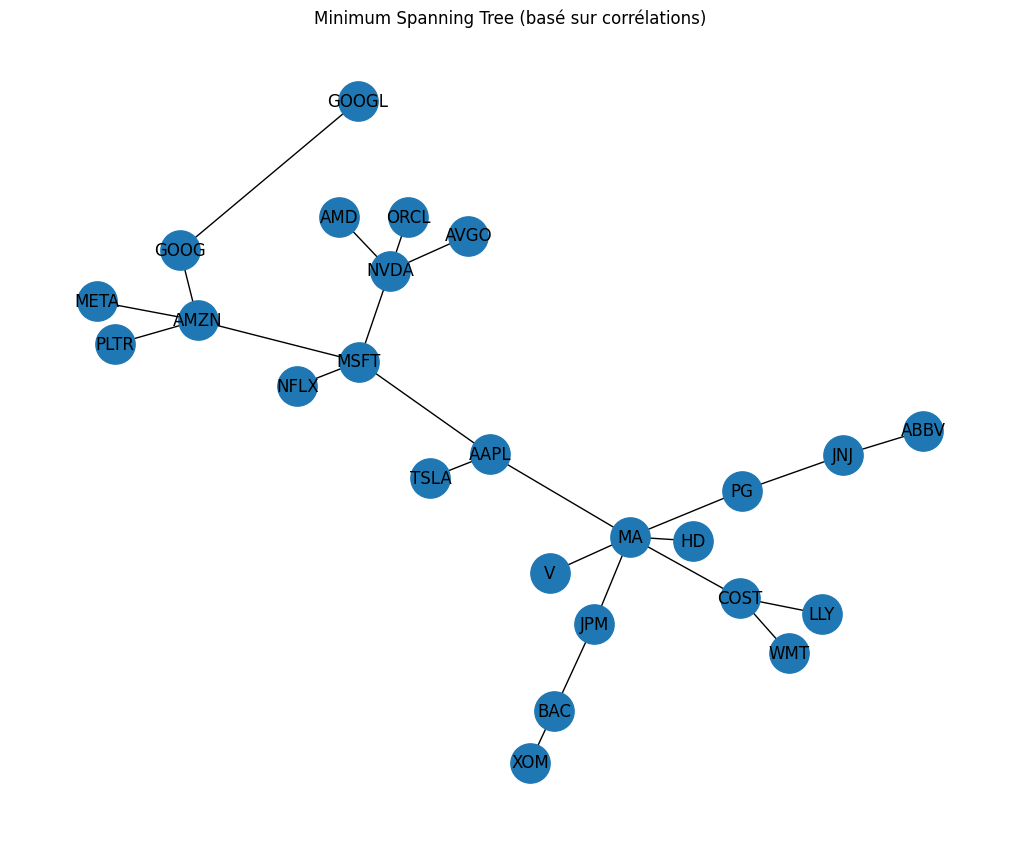

In [17]:
distance_matrix = np.sqrt(2 * (1 - corr_matrix))

G_full = nx.Graph()

for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i != j:
            G_full.add_edge(i, j, weight=distance_matrix.loc[i, j])

mst = nx.minimum_spanning_tree(G_full, weight='weight')

plt.figure(figsize=(10,8))
pos = nx.spring_layout(mst, seed=42)
nx.draw(mst, pos, with_labels=True, node_size=800)
plt.title("Minimum Spanning Tree (basé sur corrélations)")
plt.show()